## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [23]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [24]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [25]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='../data/hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [26]:

size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                      transforms.RandomVerticalFlip(), 
                                      transforms.RandomHorizontalFlip(), 
                                      transforms.GaussianBlur(3), 
                                      transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 128
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

Let's look at some images from our data 

torch.Size([3, 128, 128])


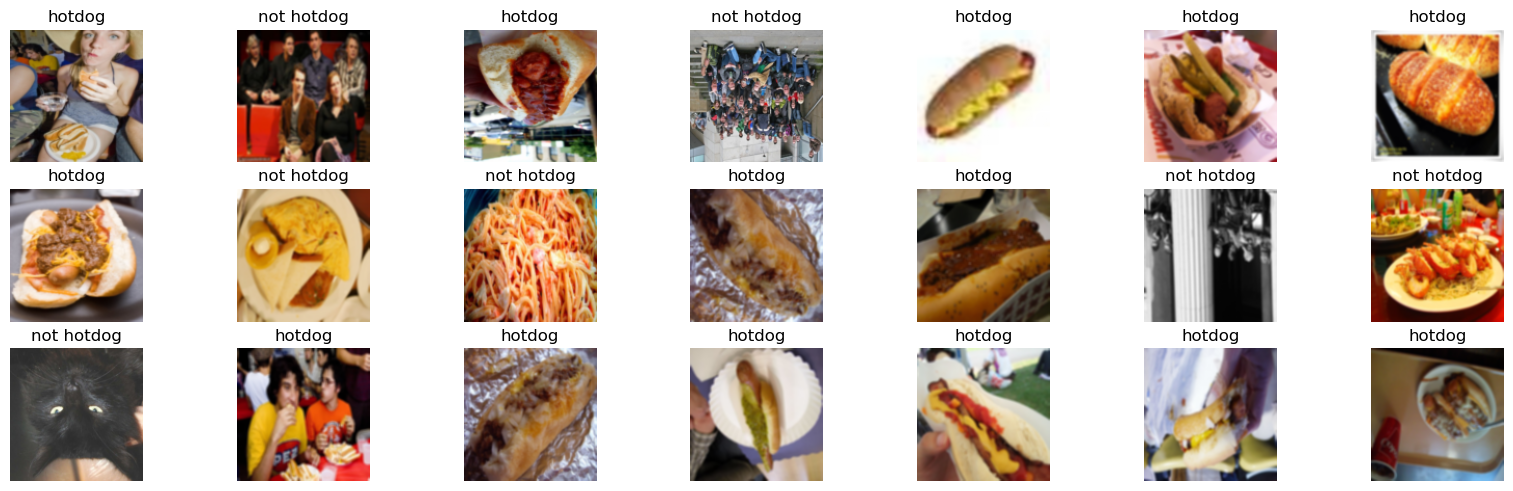

In [27]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))
print(images[0].shape)
for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 定义残差块（Basic Block）
class BasicBlock(nn.Module):
    expansion = 1  # 用于控制输出通道数的扩展

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 第二个卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample  # 用于调整输入尺寸和通道数
        self.stride = stride

    def forward(self, x):
        identity = x  # 跳跃连接保留输入

        # 前向传播：两层卷积
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 如果存在下采样层，则调整输入尺寸
        if self.downsample is not None:
            identity = self.downsample(x)

        # 将残差加到输出中
        out += identity
        out = self.relu(out)

        return out

# 定义 ResNet18 主架构
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=2):
        super(ResNet, self).__init__()
        self.in_channels = 64  # 初始通道数

        # ResNet 的第一个卷积层
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet 的 4 层（每层由多个残差块组成）
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # 全局平均池化层和全连接层
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None

        # 如果输入和输出通道不一致，或者步长不为 1，则进行下采样
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        # 第一个残差块，可能会有下采样
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        # 剩余的残差块
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # 初始卷积层
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # 4 层残差网络
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # 全局平均池化和全连接层
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = self.softmax(x)

        return x

# 构建 ResNet18 模型
def ResNet18(num_classes=1):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)

In [ ]:
model = ResNet18(num_classes=2)  # Fixed: should be 2 classes for binary classification
model.to(device)
#Initialize the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, )

#Get the first minibatch
data = next(iter(train_loader))[0]
#Try running the model on a minibatch
# print('Shape of the output from the convolutional part', model.convolutional(data).shape)
model(data); #if this runs the model dimensions fit

  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 67.9%	 test: 48.1%


  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 75.7%	 test: 54.7%


...

Accuracy train: 83.5%	 test: 74.3%


  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 83.2%	 test: 73.6%


  0%|          | 0/16 [00:00<?, ?it/s]

Accuracy train: 85.0%	 test: 69.4%


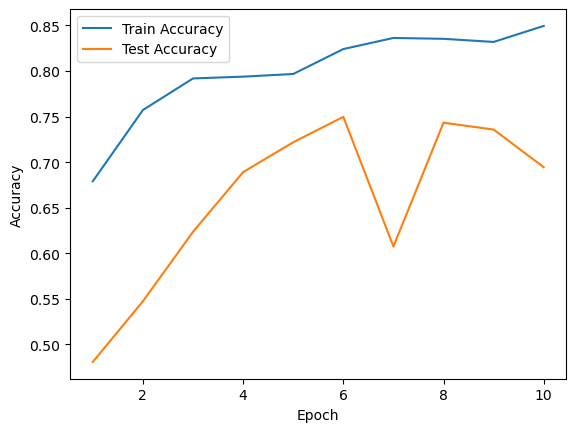

In [30]:
num_epochs = 10
train_acc_list = []
test_acc_list = []

for epoch in tqdm(range(num_epochs), unit='epoch'):
    model.train()
    train_correct = 0
    for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        # Removed print(output) to avoid flooding output
        loss = F.cross_entropy(output, target)  # Fixed: use cross_entropy instead of nll_loss with log
        loss.backward()
        optimizer.step()
        predicted = output.argmax(1)
        train_correct += (target==predicted).sum().cpu().item()
    
    test_correct = 0
    model.eval()
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)  # Fixed: move target to device
        with torch.no_grad():
            output = model(data)
        predicted = output.argmax(1)  # Removed .cpu() since target is now on device
        test_correct += (target==predicted).sum().item()
    
    train_acc = train_correct/len(trainset)
    test_acc = test_correct/len(testset)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print("Accuracy train: {train:.1f}%\t test: {test:.1f}%".format(test=100*test_acc, train=100*train_acc))

plt.plot(range(1, num_epochs+1), train_acc_list, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), test_acc_list, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()